In [ ]:
pip install datasets

In [ ]:
pip install evaluate

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


<ipython-input-4-fabeb2a52329>:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


In [ ]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [ ]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [ ]:
df = df.loc[:, ['reviews.rating','reviews.text','reviews.title']]


In [ ]:
df.isnull().sum()

,0
reviews.rating,33
reviews.text,1
reviews.title,6


In [ ]:
df['reviews.rating'].value_counts()

,count
reviews.rating,
5.0,23775
4.0,8541
3.0,1499
1.0,410
2.0,402


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull()

,reviews.rating,reviews.text,reviews.title
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
34655,False,False,False
34656,False,False,False
34657,False,False,False
34658,False,False,False


In [ ]:
df.describe()

,reviews.rating
count,34620.000000
mean,4.584518
std,0.735700
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df.shape

(34620, 3)

In [ ]:
df.columns.duplicated()

array([False, False, False])

In [ ]:
def map_rating_to_sentiment(rating):
    if rating in [1, 2]:
        return 2
    elif rating == 3:
        return 0
    else:
        return 1

df["sentiment"] = df["reviews.rating"].apply(map_rating_to_sentiment)


In [ ]:
df['reviews.rating'].unique()

array([5., 4., 2., 1., 3.])

In [ ]:
df.head()

,reviews.rating,reviews.text,reviews.title,sentiment
0,5.0,This product so far has not disappointed. My c...,Kindle,1
1,5.0,great for beginner or experienced person. Boug...,very fast,1
2,5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,1
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,1
4,5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,1


In [ ]:
df.sentiment.value_counts()

,count
sentiment,
1,32309
0,1499
2,812


In [ ]:
clean_df = df.copy()

In [ ]:
clean_df.sentiment.value_counts() # checking label distribution

,count
sentiment,
1,32309
0,1499
2,812


In [ ]:
from random import sample
# create balanced datase
negative_reviews = clean_df[clean_df['sentiment'] == 0].sample(n=5000, replace=True)
neutral_reviews = clean_df[clean_df['sentiment'] == 1].sample(n=5000, replace=True)
positive_reviews = clean_df[clean_df['sentiment'] == 2].sample(n=5000, replace=True)

sampled_df = pd.concat([negative_reviews, neutral_reviews, positive_reviews])

In [ ]:
sampled_df.sentiment.value_counts() # checking label distribution

,count
sentiment,
0,5000
1,5000
2,5000


In [ ]:
sampled_df.isnull().sum()

,0
reviews.rating,0
reviews.text,0
reviews.title,0
sentiment,0


In [ ]:
sampled_df["review_body"] = sampled_df["reviews.title"].astype(str) + ". " + sampled_df["reviews.text"].astype(str)


In [ ]:
sampled_df

,reviews.rating,reviews.text,reviews.title,sentiment,review_body
34058,3.0,I tried giving this a chance being that I'm an...,I like Apple TV better!,0,I like Apple TV better!. I tried giving this a...
7076,3.0,Over all the product is good and works as adve...,Good for the sale price,0,Good for the sale price. Over all the product ...
29271,3.0,"This product is ok, wasn't too impressed with ...",Ok product,0,"Ok product. This product is ok, wasn't too imp..."
21109,3.0,turning pages not as easy as the original ones...,convenient size,0,convenient size. turning pages not as easy as ...
29599,3.0,"I'm mostly happy, but like so many electronics...",Slow to get where you want to be,0,Slow to get where you want to be. I'm mostly h...
...,...,...,...,...,...
13721,2.0,Love everything about the unit except that it ...,Acceptable for the price,2,Acceptable for the price. Love everything abou...
6147,1.0,Honestly the worst tablet ever owned. Was very...,Kindle tablet,2,Kindle tablet. Honestly the worst tablet ever ...
12194,1.0,I bought this as a birthday gift a few weeks b...,Broken straight out of package,2,Broken straight out of package. I bought this ...
11803,2.0,This really isn't a very good tablet by any me...,Worth what I paid,2,Worth what I paid. This really isn't a very go...


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
import torch
from datasets import Dataset

In [ ]:
# Assuming df is your dataframe and you combined title + text into 'review_body'
sampled_df["label"] = sampled_df["sentiment"]  # rename to 'label' for Hugging Face compatibility
sampledf = sampled_df[["review_body", "label"]]

# Split into train and test
train_df, test_df = train_test_split(sampledf, test_size=0.2, random_state=42, stratify=sampledf["label"])


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [ ]:
model_1 = "distilbert-base-uncased"
model_2 = "bert-base-uncased"
model_3 = "roberta-base"


In [ ]:
# use tokenizer from Distilbert model

tokenizer = AutoTokenizer.from_pretrained(model_3)
model = AutoModelForSequenceClassification.from_pretrained(model_3, num_labels=3)  # 3 classes: negative, neutral, positive

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize_function(example):
    return tokenizer(example["review_body"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
)


In [ ]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    precision = precision_metric.compute(predictions=predictions, references=labels, average='weighted')
    recall = recall_metric.compute(predictions=predictions, references=labels, average='weighted')

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
import wandb
wandb.init(project="NLP Project")


eval/accuracy,▁▇███
eval/f1,▁▇███
eval/loss,█▁▁▁▁
eval/precision,▁▇███
eval/recall,▁▇███
eval/runtime,█▆▁▇▆
eval/samples_per_second,▁▃█▂▃
eval/steps_per_second,▁▃█▂▃
test/accuracy,▁
test/f1,▁
test/loss,▁


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.585900,0.325945,0.886333,0.887145,0.888814,0.886333
2,0.209900,0.256869,0.929333,0.929342,0.929632,0.929333
3,0.134200,0.282668,0.949333,0.949297,0.949309,0.949333
4,0.065300,0.290449,0.952000,0.951944,0.952715,0.952000


TrainOutput(global_step=3000, training_loss=0.23517365900675455, metrics={'train_runtime': 4821.9857, 'train_samples_per_second': 9.954, 'train_steps_per_second': 0.622, 'total_flos': 1.2629444050944e+16, 'train_loss': 0.23517365900675455, 'epoch': 4.0})

In [ ]:
results = trainer.evaluate()
results


{'eval_loss': 0.2904493510723114,
 'eval_accuracy': 0.952,
 'eval_f1': 0.9519443680296469,
 'eval_precision': 0.9527149114094864,
 'eval_recall': 0.952,
 'eval_runtime': 82.7777,
 'eval_samples_per_second': 36.242,
 'eval_steps_per_second': 2.271,
 'epoch': 4.0}

In [ ]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


In [ ]:
from sklearn.metrics import classification_report
s
print(classification_report(y_true, y_pred, target_names=["Neutral", "Positive", "Negative"]))

              precision    recall  f1-score   support

     Neutral       0.91      0.95      0.93      1000
    Positive       0.96      0.91      0.93      1000
    Negative       0.99      0.99      0.99      1000

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



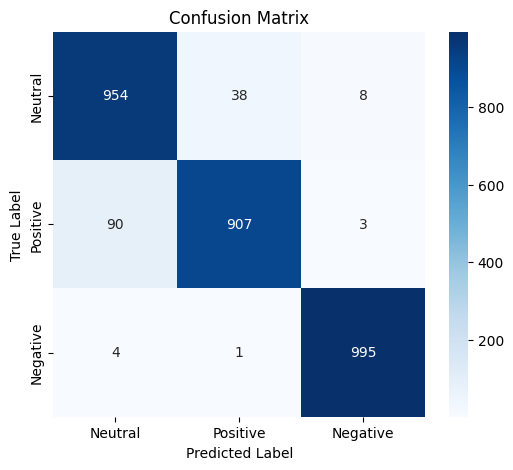

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Label mapping based on your dataset (adjust if needed)
labels = ["Neutral", "Positive", "Negative"]

# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
s

In [ ]:
trainer.save_model("./best_model")  # saves model, tokenizer, config
tokenizer.save_pretrained("./best_model")


('./best_model/tokenizer_config.json',
 './best_model/special_tokens_map.json',
 './best_model/vocab.json',
 './best_model/merges.txt',
 './best_model/added_tokens.json',
 './best_model/tokenizer.json')

In [ ]:
import shutil
shutil.make_archive("best_model", "zip", '/content/best_model')
s

'/content/best_model.zip'